In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense, Dropout
import streamlit as st
from PIL import Image

In [11]:
train_val_images = np.load("train_images.npy/train_images.npy")
train_val_labels = np.load("train_labels.npy")

test_images = np.load("test_images.npy/test_images.npy")
test_labels = np.load("test_labels.npy")

print(train_val_images.shape)
print(train_val_labels.shape)

(60000, 28, 28)
(60000,)


In [12]:
split = int(train_val_images.shape[0] * 0.9)

train_images = train_val_images[:split]
train_labels = train_val_labels[:split]

val_images = train_val_images[split:]
val_labels = train_val_labels[split:]

In [13]:
print(train_images.shape)
print(train_labels.shape)

(54000, 28, 28)
(54000,)


In [14]:
print(val_images.shape)
print(val_labels.shape)

(6000, 28, 28)
(6000,)


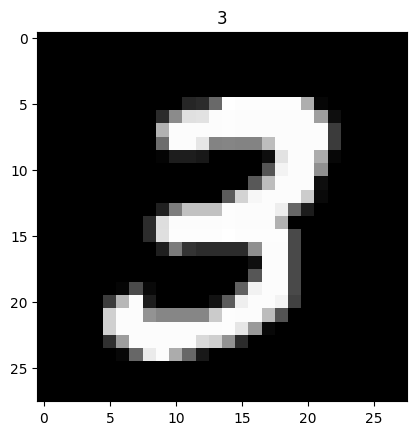

In [15]:
plt.imshow(train_images[7], cmap="gray")
plt.title(train_labels[7])
plt.show()

In [16]:
#normalization
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

In [40]:
#vectorization
train_images = train_images.reshape(-1, 784)
val_images = val_images.reshape(-1, 784)
test_images = test_images.reshape(-1, 784)

In [41]:
model = Sequential([
    
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

c:\Users\Hp\OneDrive\Documents\Scraping_task_debi_1\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(val_images, val_labels)
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8887 - loss: 0.3621 - val_accuracy: 0.9665 - val_loss: 0.1070
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9508 - loss: 0.1639 - val_accuracy: 0.9742 - val_loss: 0.0851
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9617 - loss: 0.1288 - val_accuracy: 0.9760 - val_loss: 0.0816
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9674 - loss: 0.1065 - val_accuracy: 0.9777 - val_loss: 0.0703
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9711 - loss: 0.0935 - val_accuracy: 0.9783 - val_loss: 0.0721
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9730 - loss: 0.0862 - val_accuracy: 0.9817 - val_loss: 0.0672
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9758 - loss: 0.0781 - val_accuracy: 0.9798 - val_loss: 0.0741
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9786 - loss: 0.0699 - val_accurac

In [44]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0694
Test Accuracy: 0.980400025844574


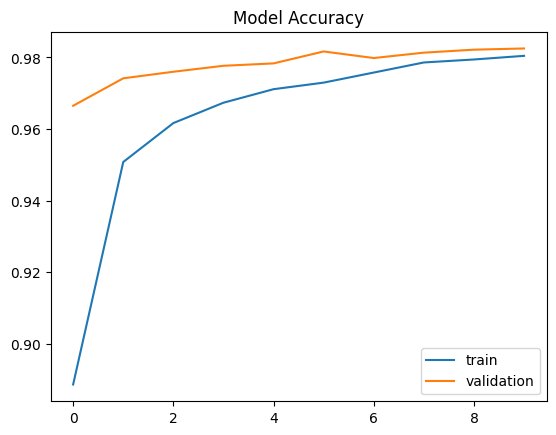

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.title("Model Accuracy")
plt.show()

## improving accuracy by increasing number of epocs and using CNN

In [18]:
train_images = train_images.reshape(-1,28,28,1)
val_images = val_images.reshape(-1,28,28,1)
test_images = test_images.reshape(-1,28,28,1)

In [9]:
model = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
MaxPooling2D((2,2)),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D((2,2)),

Flatten(),

Dense(128,activation='relu'),
Dense(10,activation='softmax')

])

c:\Users\Hp\OneDrive\Documents\Scraping_task_debi_1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=64,
    validation_data=(val_images, val_labels)
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9471 - loss: 0.1749 - val_accuracy: 0.9842 - val_loss: 0.0509
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9834 - loss: 0.0536 - val_accuracy: 0.9880 - val_loss: 0.0426
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9886 - loss: 0.0363 - val_accuracy: 0.9870 - val_loss: 0.0413
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9907 - loss: 0.0275 - val_accuracy: 0.9880 - val_loss: 0.0395
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9885 - val_loss: 0.0410
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9951 - loss: 0.0154 - val_accuracy: 0.9920 - val_loss: 0.0333
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9952 - loss: 0.0133 - val_accuracy: 0.9900 - val_loss: 0.0399
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9970 - loss: 0.0096 - 

In [57]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0477
Test Accuracy: 0.9908000230789185


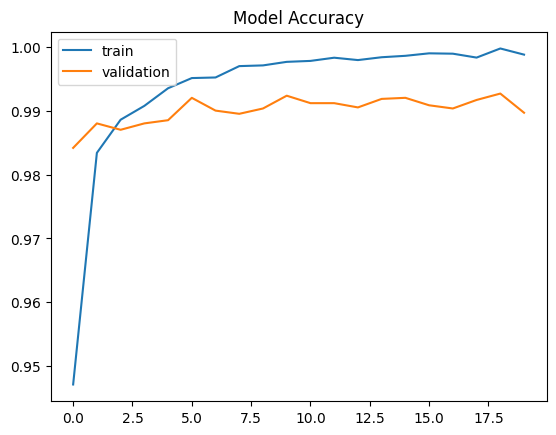

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.title("Model Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted: 7
Actual: 7


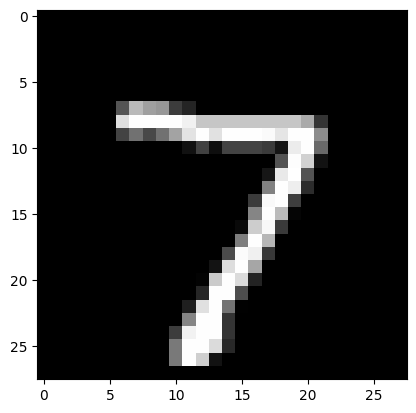

In [59]:
img = test_images[0]

prediction = model.predict(img.reshape(-1,28,28,1))

predicted_digit = np.argmax(prediction)

print("Predicted:", predicted_digit)
print("Actual:", test_labels[0])

plt.imshow(img.reshape(28,28), cmap="gray")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted: 9
Actual: 9


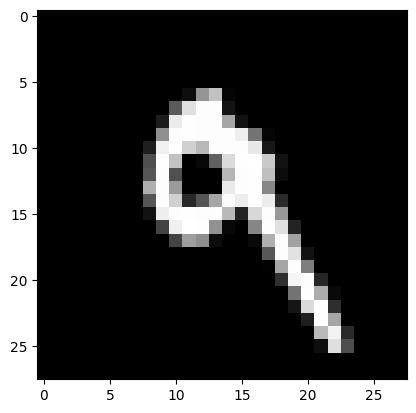

In [60]:
img = test_images[7]

prediction = model.predict(img.reshape(-1,28,28,1))

predicted_digit = np.argmax(prediction)

print("Predicted:", predicted_digit)
print("Actual:", test_labels[7])

plt.imshow(img.reshape(28,28), cmap="gray")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted digit: 1


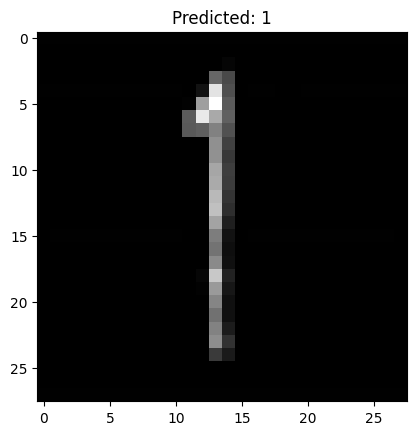

In [111]:
img = Image.open("one.jpg").convert("L")
img = img.resize((28,28))
img = np.array(img)

img = img / 255.0
#img = 255 - img
img = img.reshape(-1,28,28,1)


prediction = model.predict(img)
digit = np.argmax(prediction)
print("Predicted digit:", digit)

plt.imshow(img.reshape(28,28), cmap="gray")
plt.title(f"Predicted: {digit}")
plt.show()

In [112]:
confidence = np.max(prediction)

print("Confidence:", confidence)

Confidence: 0.99881303


In [113]:
model.save("mnist_model.h5")